# Data Cleaning and Initial Exploration

## 1. Read Data Files



In [78]:
import pandas as pd
import numpy as np
import plotly.express as px
Own_Funds_Original=pd.read_csv("SQ_Own_Funds.csv",encoding="latin1")
Balance_Sheet_Original=pd.read_csv("SQ_Balance_Sheet.csv",encoding="latin1")
Premiums_Original=pd.read_csv("SQ_Premiums_Claims_Expenses.csv",encoding="latin1")

In [79]:
Own_Funds_Original.head()

,Reporting country,Reference period,Item code,Item name,Value,Undertaking type,Date of extraction (yyyymmdd),"Number of submissions (per reporting country, reference date and undertaking type)"
0,AUSTRIA,2016 Q3,R0500,Total available own funds to meet the SCR,856.112328,Life undertakings,20250930,7
1,AUSTRIA,2016 Q3,R0500,Total available own funds to meet the SCR,16353.071138,Non-Life undertakings,20250930,15
2,AUSTRIA,2016 Q3,R0500,Total available own funds to meet the SCR,15943.253781,Other undertakings,20250930,19
3,AUSTRIA,2016 Q3,R0510,Total available own funds to meet the MCR,856.112328,Life undertakings,20250930,7
4,AUSTRIA,2016 Q3,R0510,Total available own funds to meet the MCR,16316.286682,Non-Life undertakings,20250930,15


### Create Dictionary of Codes

In [80]:
Balance_Sheet_Original['Item code'] = Balance_Sheet_Original['Item code'].astype(str) + '_BS'
Premiums_Original['Item code'] = Premiums_Original['Item code'].astype(str) + '_P'
Own_Funds_Original['Item code'] = Own_Funds_Original['Item code'].astype(str) + '_O'

In [81]:
Codes = (
    pd.concat([
        Balance_Sheet_Original[['Item code', 'Item name']],
        Premiums_Original[['Item code', 'Item']].rename(columns={'Item': 'Item name'}),
        Own_Funds_Original[['Item code', 'Item name']]
    ])
    .drop_duplicates(subset=['Item code'])
    .reset_index(drop=True))

In [82]:
Codes.tail(2)

,Item code,Item name
155,R0540 - C0040_O,EOF Tier 2
156,R0540 - C0050_O,EOF Tier 3


####Fix the Reference Period

In [83]:
Balance_Sheet_Original['Year'] = Balance_Sheet_Original['Reference period'].str.extract(r'(\d{4})').astype(int)
Balance_Sheet_Original['Quarter'] = Balance_Sheet_Original['Reference period'].str.extract(r'(Q\d)')[0]
Balance_Sheet_Original['Date'] = pd.PeriodIndex(    Balance_Sheet_Original['Year'].astype(str) + Balance_Sheet_Original['Quarter'],freq='Q').to_timestamp()
Balance_Sheet_Original.drop(columns=['Year', 'Quarter'], inplace=True)

In [84]:
Premiums_Original['Year'] = Premiums_Original['Reference period'].str.extract(r'(\d{4})').astype(int)
Premiums_Original['Quarter'] = Premiums_Original['Reference period'].str.extract(r'(Q\d)')[0]
Premiums_Original['Date'] = pd.PeriodIndex(Premiums_Original['Year'].astype(str) + Premiums_Original['Quarter'],freq='Q').to_timestamp()
Premiums_Original.drop(columns=['Year', 'Quarter'], inplace=True)

In [85]:
Own_Funds_Original['Year'] = Own_Funds_Original['Reference period'].str.extract(r'(\d{4})').astype(int)
Own_Funds_Original['Quarter'] = Own_Funds_Original['Reference period'].str.extract(r'(Q\d)')[0]
Own_Funds_Original['Date'] = pd.PeriodIndex(Own_Funds_Original['Year'].astype(str) + Own_Funds_Original['Quarter'],freq='Q').to_timestamp()
Own_Funds_Original.drop(columns=['Year', 'Quarter'], inplace=True)

In [86]:
Own_Funds_Original

,Reporting country,Reference period,Item code,Item name,Value,Undertaking type,Date of extraction (yyyymmdd),"Number of submissions (per reporting country, reference date and undertaking type)",Date
0,AUSTRIA,2016 Q3,R0500_O,Total available own funds to meet the SCR,856.112328,Life undertakings,20250930,7,2016-07-01
1,AUSTRIA,2016 Q3,R0500_O,Total available own funds to meet the SCR,16353.071138,Non-Life undertakings,20250930,15,2016-07-01
2,AUSTRIA,2016 Q3,R0500_O,Total available own funds to meet the SCR,15943.253781,Other undertakings,20250930,19,2016-07-01
3,AUSTRIA,2016 Q3,R0510_O,Total available own funds to meet the MCR,856.112328,Life undertakings,20250930,7,2016-07-01
4,AUSTRIA,2016 Q3,R0510_O,Total available own funds to meet the MCR,16316.286682,Non-Life undertakings,20250930,15,2016-07-01
...,...,...,...,...,...,...,...,...,...
66250,SWEDEN,2025 Q2,R0640_P75_O,Ratio of Eligible own funds to MCR (P75),6.988910,Other undertakings,20250930,14,2025-04-01
66251,SWEDEN,2025 Q2,R0640_P90_O,Ratio of Eligible own funds to MCR (P90),8.613950,All undertaking types,20250930,113,2025-04-01
66252,SWEDEN,2025 Q2,R0640_P90_O,Ratio of Eligible own funds to MCR (P90),5.434460,Life undertakings,20250930,14,2025-04-01
66253,SWEDEN,2025 Q2,R0640_P90_O,Ratio of Eligible own funds to MCR (P90),8.681020,Non-Life undertakings,20250930,85,2025-04-01


## 2. Restructure the data bases

1. Use only the columns we are interested

In [87]:
Balance_Sheet = Balance_Sheet_Original[['Reporting country','Date', 'Value','Item code']]
Premiums = Premiums_Original[['Reporting country','Date', 'Value','Item code']]
Own_Funds = Own_Funds_Original[['Reporting country','Date', 'Value','Item code']]



2.   Long to Wide format



In [88]:
Balance_Sheet_wide = (
    Balance_Sheet.pivot_table(
        index=['Reporting country', 'Date'],
        columns='Item code',
        values='Value',
        aggfunc='sum',           # ✅ sum duplicates
        fill_value=0             # optional: replace NaNs with 0
    )
    .reset_index()
)

Premiums_wide = (
    Premiums.pivot_table(
        index=['Reporting country', 'Date'],
        columns='Item code',
        values='Value',
        aggfunc='sum',           # ✅ sum duplicates
        fill_value=0
    )
    .reset_index()
)

Own_Funds_wide = (
    Own_Funds.pivot_table(
        index=['Reporting country', 'Date'],
        columns='Item code',
        values='Value',
        aggfunc='sum',           # ✅ sum duplicates
        fill_value=0
    )
    .reset_index()
)


In [89]:
Balance_Sheet_wide.head(2)

Item code,Reporting country,Date,R0001_BS,R0010_BS,R0020_BS,R0030_BS,R0040_BS,R0050_BS,R0060_BS,R0070_BS,...,R0810_BS,R0820_BS,R0830_BS,R0840_BS,R0850_BS,R0860_BS,R0870_BS,R0880_BS,R0900_BS,R1000_BS
0,AUSTRIA,2016-07-01,0.0,0.0,0.0,0.0,1906.768025,49.408931,904.896925,102848.059472,...,566.429698,596.602407,675.716662,1901.797149,3537.720381,0.000000,3537.720381,618.188377,111158.596047,30248.404527
1,AUSTRIA,2016-10-01,0.0,0.0,0.0,0.0,1240.440968,48.256793,975.785244,102945.441183,...,586.810630,852.301742,493.989152,1691.547709,3384.804249,260.855371,3123.948878,418.481195,105145.325667,34262.491946


In [90]:
Premiums_wide.head(2)

Item code,Reporting country,Date,R0101_P,R0110_P,R0120_P,R0130_P,R0140_P,R0200_P,R0201_P,R0210_P,...,R1701_P,R1710_P,R1720_P,R1800_P,R1900_P,R2500_P,R2510_P,R2600_P,Z0001_P,Z0002_P
0,AUSTRIA,2016-07-01,0.0,7014.674593,1227.558933,30.519672,2577.818515,5694.934683,0.0,6658.226021,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AUSTRIA,2016-10-01,0.0,8820.385891,1614.834650,46.186761,3317.361617,7164.045685,0.0,8806.180214,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


3.   Exclude 'EEA' from the 'Countries' in Premiums



In [91]:
Premiums_wide=Premiums_wide[Premiums_wide['Reporting country']!='EEA']
Own_Funds_wide=Own_Funds_wide[Own_Funds_wide['Reporting country']!='EEA']

## 3. Merge the Data Bases

In [92]:
df = pd.merge(Balance_Sheet_wide, Premiums_wide, on=["Reporting country", "Date"], how="outer")
df = pd.merge(df, Own_Funds_wide, on=["Reporting country", "Date"], how="outer")
df.head(3)

Item code,Reporting country,Date,R0001_BS,R0010_BS,R0020_BS,R0030_BS,R0040_BS,R0050_BS,R0060_BS,R0070_BS,...,R0620_P25_O,R0620_P50_O,R0620_P75_O,R0620_P90_O,R0640_O,R0640_P10_O,R0640_P25_O,R0640_P50_O,R0640_P75_O,R0640_P90_O
0,AUSTRIA,2016-07-01,0.0,0.0,0.0,0.0,1906.768025,49.408931,904.896925,102848.059472,...,7.52010,9.64732,11.55703,13.46049,29.20316,13.38675,18.88067,25.71791,33.20640,39.99726
1,AUSTRIA,2016-10-01,0.0,0.0,0.0,0.0,1240.440968,48.256793,975.785244,102945.441183,...,8.55114,10.24471,12.08615,13.66983,33.52924,15.91609,22.11017,28.80159,36.44562,42.62757
2,AUSTRIA,2017-01-01,0.0,0.0,0.0,0.0,1096.443040,48.134599,918.344415,102288.682296,...,8.30067,10.27427,11.74052,14.39609,32.20706,16.74696,21.42416,27.99324,36.07590,42.66843


In [93]:
print("Balance_Sheet shape:", Balance_Sheet_wide.shape)
print("Premiums shape:", Premiums_wide.shape)
print("Own_Funds shape:", Own_Funds_wide.shape)
print("df shape:", df.shape)

Balance_Sheet shape: (1079, 87)
Premiums shape: (1079, 52)
Own_Funds shape: (1079, 24)
df shape: (1079, 159)


## 4. Missing Values and format

1. Replace N/A with 0


In [94]:
df = df.fillna(0)

2.   Make sure all columns except 'Reporting country' and 'Date' are float and round to 2 decimals.



In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1079 entries, 0 to 1078
Columns: 159 entries, Reporting country to R0640_P90_O
dtypes: datetime64[ns](1), float64(157), object(1)
memory usage: 1.3+ MB


In [96]:
df

Item code,Reporting country,Date,R0001_BS,R0010_BS,R0020_BS,R0030_BS,R0040_BS,R0050_BS,R0060_BS,R0070_BS,...,R0620_P25_O,R0620_P50_O,R0620_P75_O,R0620_P90_O,R0640_O,R0640_P10_O,R0640_P25_O,R0640_P50_O,R0640_P75_O,R0640_P90_O
0,AUSTRIA,2016-07-01,0.0,0.0,0.0,0.000000,1906.768025,49.408931,904.896925,102848.059472,...,7.52010,9.64732,11.55703,13.46049,29.20316,13.38675,18.88067,25.71791,33.20640,39.99726
1,AUSTRIA,2016-10-01,0.0,0.0,0.0,0.000000,1240.440968,48.256793,975.785244,102945.441183,...,8.55114,10.24471,12.08615,13.66983,33.52924,15.91609,22.11017,28.80159,36.44562,42.62757
2,AUSTRIA,2017-01-01,0.0,0.0,0.0,0.000000,1096.443040,48.134599,918.344415,102288.682296,...,8.30067,10.27427,11.74052,14.39609,32.20706,16.74696,21.42416,27.99324,36.07590,42.66843
3,AUSTRIA,2017-04-01,0.0,0.0,0.0,0.000000,1036.858955,47.654477,874.071136,103652.429316,...,8.42845,10.15729,11.73763,14.52526,33.56952,16.98614,21.98091,28.55037,36.41205,40.60989
4,AUSTRIA,2017-07-01,0.0,0.0,0.0,0.000000,1035.099143,47.136376,892.174582,104608.597045,...,8.54471,10.35783,11.90962,14.47787,34.01060,17.24452,22.66969,28.94775,37.88953,41.83012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1074,SWEDEN,2024-04-01,0.0,0.0,0.0,0.255971,39.305836,37.209800,830.547269,147198.407775,...,6.34952,7.49844,9.32786,12.29437,26.54571,11.03007,15.92613,22.05167,28.00403,33.23887
1075,SWEDEN,2024-07-01,0.0,0.0,0.0,0.300532,33.398470,33.637802,825.054867,150001.674758,...,6.41708,7.62682,9.27234,11.60056,26.65424,11.56036,16.36059,22.11700,28.14620,33.56828
1076,SWEDEN,2024-10-01,0.0,0.0,0.0,0.000000,35.017581,41.083958,827.626389,146952.384948,...,6.30095,7.22668,8.68717,11.32406,26.23922,11.22487,15.83877,22.19289,27.17214,33.91020
1077,SWEDEN,2025-01-01,0.0,0.0,0.0,0.000000,51.763969,59.701292,879.182643,152333.967558,...,6.31592,7.25802,8.73743,10.68130,25.86379,10.95717,15.85985,21.74968,26.87912,31.02951


In [97]:
num_cols = df.columns.difference(['Reporting country', 'Date'])
df[num_cols] = df[num_cols].astype(float)
df[num_cols] = df[num_cols].round(2)

In [98]:
num_cols = df.columns.difference(['Reporting country', 'Date'])

for col in num_cols:
    # mask of values that can't be converted
    mask = pd.to_numeric(df[col], errors='coerce').isna() & df[col].notna()
    if mask.any():
        print(f"Column: {col}")
        print(df.loc[mask, col])


In [99]:
df.tail(4)

Item code,Reporting country,Date,R0001_BS,R0010_BS,R0020_BS,R0030_BS,R0040_BS,R0050_BS,R0060_BS,R0070_BS,...,R0620_P25_O,R0620_P50_O,R0620_P75_O,R0620_P90_O,R0640_O,R0640_P10_O,R0640_P25_O,R0640_P50_O,R0640_P75_O,R0640_P90_O
1075,SWEDEN,2024-07-01,0.0,0.0,0.0,0.3,33.40,33.64,825.05,150001.67,...,6.42,7.63,9.27,11.60,26.65,11.56,16.36,22.12,28.15,33.57
1076,SWEDEN,2024-10-01,0.0,0.0,0.0,0.0,35.02,41.08,827.63,146952.38,...,6.30,7.23,8.69,11.32,26.24,11.22,15.84,22.19,27.17,33.91
1077,SWEDEN,2025-01-01,0.0,0.0,0.0,0.0,51.76,59.70,879.18,152333.97,...,6.32,7.26,8.74,10.68,25.86,10.96,15.86,21.75,26.88,31.03
1078,SWEDEN,2025-04-01,0.0,0.0,0.0,0.0,49.89,54.37,852.81,149996.78,...,6.33,7.52,8.71,11.13,25.60,11.69,16.42,21.89,26.82,31.07


## 5. Check for duplicates

In [100]:
duplicates = df[df.duplicated(subset=['Reporting country', 'Date'], keep=False)]
print(duplicates)
print(f"\nTotal duplicated rows: {len(duplicates)}")


Empty DataFrame
Columns: [Reporting country, Date, R0001_BS, R0010_BS, R0020_BS, R0030_BS, R0040_BS, R0050_BS, R0060_BS, R0070_BS, R0080_BS, R0090_BS, R0100_BS, R0110_BS, R0120_BS, R0130_BS, R0140_BS, R0150_BS, R0160_BS, R0170_BS, R0180_BS, R0190_BS, R0200_BS, R0210_BS, R0220_BS, R0230_BS, R0240_BS, R0250_BS, R0260_BS, R0270_BS, R0280_BS, R0290_BS, R0300_BS, R0310_BS, R0320_BS, R0330_BS, R0340_BS, R0350_BS, R0360_BS, R0370_BS, R0380_BS, R0390_BS, R0400_BS, R0410_BS, R0420_BS, R0500_BS, R0501_BS, R0510_BS, R0520_BS, R0530_BS, R0540_BS, R0550_BS, R0560_BS, R0570_BS, R0580_BS, R0590_BS, R0600_BS, R0610_BS, R0620_BS, R0630_BS, R0640_BS, R0650_BS, R0660_BS, R0670_BS, R0680_BS, R0690_BS, R0700_BS, R0710_BS, R0720_BS, R0730_BS, R0740_BS, R0750_BS, R0760_BS, R0770_BS, R0780_BS, R0790_BS, R0800_BS, R0810_BS, R0820_BS, R0830_BS, R0840_BS, R0850_BS, R0860_BS, R0870_BS, R0880_BS, R0900_BS, R1000_BS, R0101_P, R0110_P, R0120_P, R0130_P, R0140_P, R0200_P, R0201_P, R0210_P, R0220_P, R0230_P, R0240_P, 

# Research question 3: data processing

In [101]:
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

columns_of_interest = [
    "Reporting country",
    "Date",
    "R0130_BS", #investments in bonds
    "R0100_BS", #investments in equities
    "R0500_BS", #total assets
    "R0200_P", # written premiums for non-life
    "R1500_P", # written premiums for life
    "R0080_BS", #Property (other than for own use)
    "R0090_BS", #Holdings in related undertakings, including participations
    "R0180_BS", #Collective Investments Undertakings
    "R0190_BS", #Derivatives 
    "R0200_BS", # Deposits other than cash equivalents 
    "R0210_BS" #Other investments 
]
data = df[columns_of_interest].copy()

# Total premiums written is the sum of written premiums for non-life and written premiums for life
data["Total premiums written"] = data["R0200_P"] + data["R1500_P"]
#Composition of the assets depending on the type of investments:
#Bonds 
data["Bonds"] = data["R0130_BS"]
#Equities
data["Equities"] = data["R0100_BS"]
#Property (other than for own use)
data["Property"] = data["R0080_BS"]
#Holding in related undertakings, including participation
data["Holding related undertakings"] = data["R0090_BS"]
data["Collective investments undertakings"] = data["R0180_BS"]
data["Derivatives"] = data["R0190_BS"]
#Deposits other than cash equivalents
data["Deposits"] = data["R0200_BS"]
data["Other investments"] = data["R0210_BS"]

## Figure 1

In [102]:
import pandas as pd
import plotly.graph_objects as go

# Parameters
main_countries = ['FRANCE', 'GERMANY', 'ITALY']
investment_vars = [
    'Bonds','Equities','Property','Holding related undertakings',
    'Collective investments undertakings','Derivatives','Deposits','Other investments'
]
default_investment = 'Bonds'
n_quantiles = 3
# Preprocessing
data['Date'] = pd.to_datetime(data['Date'])

# Exclude years 2016 and 2025 (data incomplete)
data = data[~data['Date'].dt.year.isin([2016, 2025])]

data_main  = data[data['Reporting country'].isin(main_countries)].copy()
data_other = data[~data['Reporting country'].isin(main_countries)].copy()

# Country clusters based on total premiums
country_prem = (
    data_other.groupby('Reporting country')['Total premiums written']
    .sum()
    .reset_index()
)

country_prem['cluster'] = pd.qcut(
    country_prem['Total premiums written'],
    q=n_quantiles,
    labels=['Low premiums','Medium premiums','High premiums']
)

country_to_cluster = dict(zip(country_prem['Reporting country'], country_prem['cluster']))
data_other['Premium Cluster'] = data_other['Reporting country'].map(country_to_cluster)

# France, Italy and Germany get their own cluster
data_main['Premium Cluster'] = 'Main countries (FR, IT, DE)'

data_all = pd.concat([data_main, data_other], ignore_index=True)

# Filter DataFrames by cluster
df_low   = data_all[data_all['Premium Cluster'] == 'Low premiums']
df_med   = data_all[data_all['Premium Cluster'] == 'Medium premiums']
df_high  = data_all[data_all['Premium Cluster'] == 'High premiums']
df_main2 = data_all[data_all['Premium Cluster'] == 'Main countries (FR, IT, DE)']


# Plot
def create_figure(df, title):
    fig = go.Figure()
    countries = sorted(df['Reporting country'].unique())

    # Add one trace per country
    for c in countries:
        temp = df[df['Reporting country'] == c].sort_values('Date')
        fig.add_trace(go.Scatter(
            x=temp['Date'],
            y=temp[default_investment],
            mode='markers',
            marker=dict(size=6),
            name=c
        ))

    # Dropdown to switch investment variable
    buttons = []
    for inv in investment_vars:
        y_new = [df[df['Reporting country']==c].sort_values('Date')[inv].tolist()
                 for c in countries]

        buttons.append(dict(
            label=inv,
            method='update',
            args=[{"y": y_new}, {"yaxis": {"title": inv}}]
        ))

    fig.update_layout(
        title=title,
        xaxis_title="Date",
        yaxis_title=default_investment,
        updatemenus=[dict(buttons=buttons, x=1.05, y=1.15)],
        height=500,
        width=800   
    )
    return fig


# Create and show figures
create_figure(df_low,   "Low Premium Countries").show()
create_figure(df_med,   "Medium Premium Countries").show()
create_figure(df_high,  "High Premium Countries").show()
create_figure(df_main2, "Main Countries: France, Italy, Germany").show()


## Figure 1.2?? Table containing information of cluster for Volume Premiums per Country, in order to classify different EU countries

In [103]:
# Total premiums for countries (except France, Italy, Germany)
country_prem = (
    data_other
    .groupby('Reporting country', observed=True)['Total premiums written']
    .sum()
    .reset_index()
)

# Recreate clusters
country_prem['Cluster'] = pd.qcut(
    country_prem['Total premiums written'],
    q=3,
    labels=['Low premiums', 'Medium premiums', 'High premiums']
)

# Summary table for clusters
cluster_table = (
    country_prem
    .groupby('Cluster', observed=True)['Total premiums written']
    .agg(
        min='min',
        max='max',
        mean='mean',
        count='count'
    )
    .reset_index()
)
# replace "count" by "number of countries"
cluster_table = cluster_table.rename(columns={'count': 'Number of countries'})

# Add 3 countries left in a row
main_totals = (
    data_main
    .groupby('Reporting country')['Total premiums written']
    .sum()
)

main_row = pd.DataFrame([{
    'Cluster': 'Main countries (FR, IT, DE)',
    'min': main_totals.min(),
    'max': main_totals.max(),
    'mean': main_totals.mean(),
    'Number of countries': len(main_totals)
}])

# Combine cluster table + main countries
cluster_table_final = pd.concat([cluster_table, main_row], ignore_index=True)

for col in ['min', 'max', 'mean']:
    cluster_table_final[col] = cluster_table_final[col].map(lambda x: f"{x:,.0f}")

# show final table
cluster_table_final


,Cluster,min,max,mean,Number of countries
0,Low premiums,"9,981","42,025","23,721",9
1,Medium premiums,"48,750","263,277","116,979",9
2,High premiums,"336,286","1,590,720","830,149",9
3,"Main countries (FR, IT, DE)","2,521,758","5,317,476","4,328,764",3


## Figure 2: Correlation matrix between assets types, total premiums written, per year

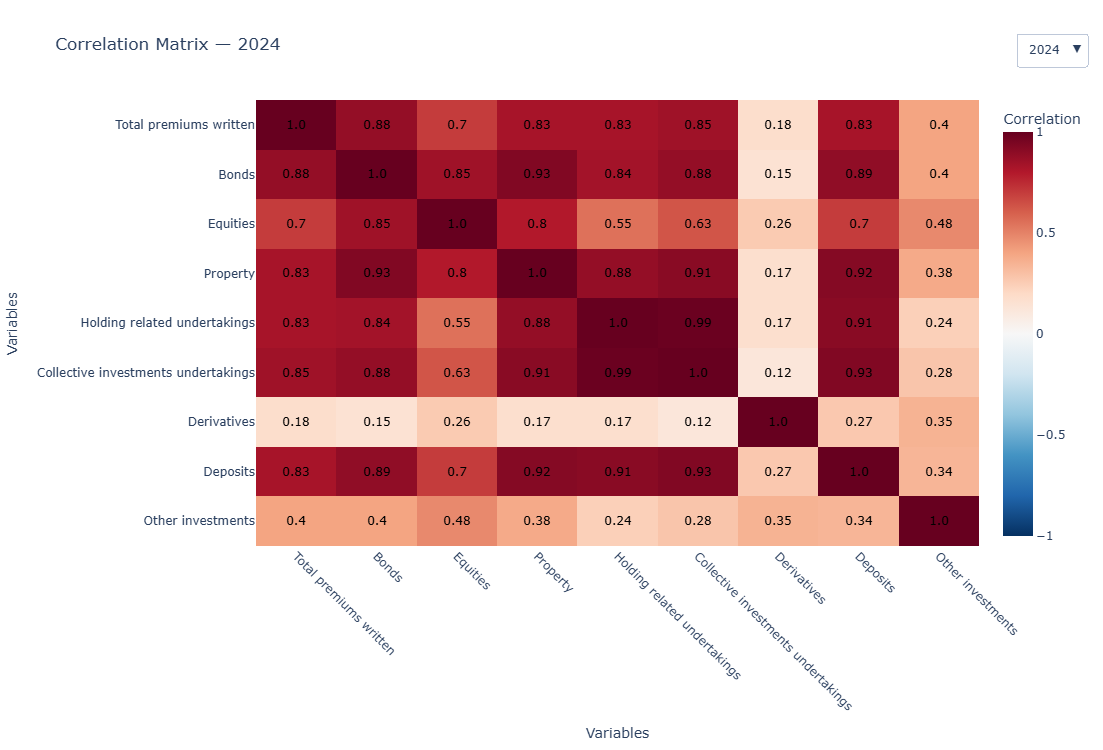

In [104]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np

data['Date'] = pd.to_datetime(data['Date'])
data['Year'] = data['Date'].dt.year

# Exclude years 2016 and 2025 (data incomplete)
data = data[~data['Date'].dt.year.isin([2016, 2025])]

# Columns to include in correlation
num_cols = [
    'Total premiums written', 'Bonds', 'Equities', 'Property',
    'Holding related undertakings', 'Collective investments undertakings',
    'Derivatives', 'Deposits', 'Other investments'
]

# Keep only existing columns
num_cols = [c for c in num_cols if c in data.columns]

years = sorted(data['Year'].unique())

# Create figure (default = latest year)
default_year = years[-1]
active_index = years.index(default_year)

# Compute correlation for each year
corr_matrices = {}
text_matrices = {}

for year in years:
    df_y = data[data['Year'] == year][num_cols]
    corr = df_y.corr().round(2)
    corr_matrices[year] = corr.values
    text_matrices[year] = corr.astype(str).values




fig = go.Figure()

fig.add_trace(go.Heatmap(
    z=corr_matrices[default_year],
    x=num_cols,
    y=num_cols,
    colorscale="RdBu_r",        # blue = -1, red = +1
    zmin=-1,
    zmax=1,
    text=text_matrices[default_year],
    texttemplate="%{text}",   # show values
    textfont={"size":12, "color":"black"},
    colorbar=dict(title="Correlation")
))

# Dropdown to select years
buttons = []

for year in years:
    buttons.append(
        dict(
            label=str(year),
            method="update",
            args=[
                {
                    "z": [corr_matrices[year]],
                    "text": [text_matrices[year]]
                },
                {
                    "title": f"Correlation Matrix — {year}"
                }
            ]
        )
    )

fig.update_layout(
    title=f"Correlation Matrix — {default_year}",
    xaxis=dict(title="Variables", tickangle=45),
    yaxis=dict(title="Variables", autorange="reversed"),
    width=750,
    height=750,
    updatemenus=[dict(
        buttons=buttons,
        direction="down",
        x=1.15, y=1.15,
        active = active_index
    )]
)

fig.show()
